# 📊 Multivariate Analysis

## 🎯 Learning Objectives

After completing this notebook, you will be able to:

- Understand Multivariate Analysis.
- Analyze relationships among three or more variables.
- Use Pivot Tables for summarizing data.
- Create grouped visualizations.
- Interpret patterns involving multiple features.
- Perform multivariate analysis using the Titanic dataset.

## 📖 Introduction

Multivariate Analysis examines the relationship between three or more variables simultaneously. It helps identify complex patterns that cannot be observed by analyzing only one or two variables.

This analysis is widely used in business analytics and machine learning to understand how multiple features influence an outcome.

## ❓ What is Multivariate Analysis?

Multivariate Analysis studies multiple variables together.

Examples:

- Sex + Pclass + Survived
- Age + Fare + Survived
- Embarked + Pclass + Fare

It helps answer questions such as:

- Did females in First Class survive more often?
- Which passenger class paid the highest average fare?
- How does age vary across survival status and passenger class?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"D:\Sanskruti\sanskruti document\Machine-Learning-From-Scratch\datasets\train.csv")

## 📌 Pivot Table

In [3]:
pivot = pd.pivot_table(
    df,
    values="Fare",
    index="Pclass",
    columns="Sex",
    aggfunc="mean"
)

pivot

Sex,female,male
Pclass,,
1,106.125798,67.226127
2,21.970121,19.741782
3,16.118810,12.661633


Explanation
Values → Fare
Rows (Index) → Passenger Class
Columns → Gender
Aggregation → Mean Fare

## 📌 GroupBy Multiple Columns

In [4]:
df.groupby(["Sex","Pclass"])["Survived"].mean()

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

In [5]:
df.groupby(["Sex","Pclass"])["Survived"].mean().reset_index()

,Sex,Pclass,Survived
0,female,1,0.968085
1,female,2,0.921053
2,female,3,0.500000
3,male,1,0.368852
4,male,2,0.157407
5,male,3,0.135447


## 📌 Crosstab with Multiple Variables

In [6]:
pd.crosstab(
    [df["Sex"], df["Pclass"]],
    df["Survived"]
)

Survived         0   1
Sex    Pclass         
female 1         3  91
       2         6  70
       3        72  72
male   1        77  45
       2        91  17
       3       300  47

## 📌 Average Age by Passenger Class and Survival

In [7]:
df.groupby(["Pclass","Survived"])["Age"].mean()

Pclass  Survived
1       0           43.695312
        1           35.368197
2       0           33.544444
        1           25.901566
3       0           26.555556
        1           20.646118
Name: Age, dtype: float64

## 📌 Average Fare by Embarked and Passenger Class

In [8]:
df.groupby(["Embarked","Pclass"])["Fare"].mean()

Embarked  Pclass
C         1         104.718529
          2          25.358335
          3          11.214083
Q         1          90.000000
          2          12.350000
          3          11.183393
S         1          70.364862
          2          20.327439
          3          14.644083
Name: Fare, dtype: float64

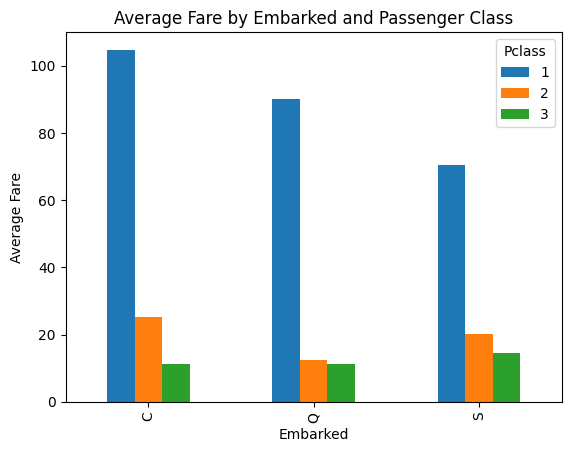

In [9]:
df.groupby(["Embarked","Pclass"])["Fare"].mean().unstack().plot(kind="bar")

plt.title("Average Fare by Embarked and Passenger Class")
plt.xlabel("Embarked")
plt.ylabel("Average Fare")
plt.show()

## 📌 Correlation Matrix

In [10]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

numeric_df.corr()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


Explain:

+1 → Strong Positive
0 → No Relationship
-1 → Strong Negative

## 🔍 Observations

- First-class female passengers had the highest survival rate.
- Average fare increased with passenger class.
- Survival rates varied across passenger classes.
- Passenger class influenced both fare and survival.

## ✅ Best Practices

- Use Pivot Tables to summarize multiple variables.
- Use GroupBy for flexible aggregation.
- Analyze relationships before feature selection.
- Validate findings with visualizations.

## 🌍 Real-World Scenario

An airline analyzes passenger data using multiple variables such as travel class, ticket price, and customer satisfaction. By studying these variables together, the company identifies premium customer segments and improves pricing and service strategies.

## 📝 Summary

In this notebook, we explored Multivariate Analysis using Pivot Tables, GroupBy, and Crosstab. We analyzed multiple variables together to uncover deeper patterns and relationships in the Titanic dataset.